## Chuẩn bị dữ liệu (train, test, val)

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Đọc dữ liệu
local_path = 'data_engineered.csv'
remote_path = 'https://raw.githubusercontent.com/phamhuongtra/depression_analysis/refs/heads/feat/model/data_engineered.csv'

try:
    df = pd.read_csv(local_path)
    print(f'Loaded local file: {local_path}')
except FileNotFoundError:
    df = pd.read_csv(remote_path)
    print(f'Local file not found. Loaded remote file: {remote_path}')

# Tách X, y
target_col = 'Depression'
X = df.drop(columns=[target_col])
y = df[target_col]

# Chia train/val/test = 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Số mẫu train: {len(X_train)}')
print(f'Số mẫu val  : {len(X_val)}')
print(f'Số mẫu test : {len(X_test)}')
print('\nTi lệ nhãn Depression trong train:')
print(y_train.value_counts(normalize=True).sort_index())

Local file not found. Loaded remote file: https://raw.githubusercontent.com/phamhuongtra/depression_analysis/refs/heads/feat/model/data_engineered.csv
Số mẫu train: 98425
Số mẫu val  : 21091
Số mẫu test : 21092

Ti lệ nhãn Depression trong train:
Depression
0    0.81839
1    0.18161
Name: proportion, dtype: float64


## Random forest

### Giới thiệu model

Random Forest là mô hình học máy dạng ensemble, kết hợp nhiều Decision Tree để đưa ra dự đoán cuối cùng bằng cơ chế bỏ phiếu. Cách làm này giúp mô hình ổn định hơn một cây đơn lẻ, giảm nguy cơ overfitting và thường hoạt động tốt trên dữ liệu có nhiều loại đặc trưng khác nhau.

### Lý do chọn model
- Dữ liệu có cả biến số và biến phân loại nên Random Forest phù hợp vì học tốt trên dữ liệu hỗn hợp và bắt được quan hệ phi tuyến.
- Mô hình ít nhạy với nhiễu, không đòi hỏi giả định tuyến tính, và vẫn hoạt động tốt khi dữ liệu còn mất cân bằng lớp.
- Kết quả cũng dễ đánh giá bằng accuracy, precision, recall, F1 và confusion matrix trong phần kiểm thử.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Lấy danh sách cột số và cột categorical
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns

# OneHot encode cho cột categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,           # số cây
        class_weight='balanced',    # xử lý mất cân bằng lớp
        random_state=42,            # cố định kết quả
        n_jobs=-1                   # dùng toàn bộ CPU để train nhanh hơn
    ))
])

### Train

In [10]:
# Train mô hình
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Working Professional or Student', 'Profession',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?',
       'Work/Study Hours', 'Family History of Mental Illness', 'Age_Group',
       'Diet_Work_Interaction', 'Sleep_Work_Interaction'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

### Đánh giá
#### Validation

Accuracy  : 0.9356
Precision : 0.8435
Recall    : 0.7922
F1-score  : 0.8170
                precision    recall  f1-score   support

Không trầm cảm       0.95      0.97      0.96     17261
      Trầm cảm       0.84      0.79      0.82      3830

      accuracy                           0.94     21091
     macro avg       0.90      0.88      0.89     21091
  weighted avg       0.93      0.94      0.93     21091



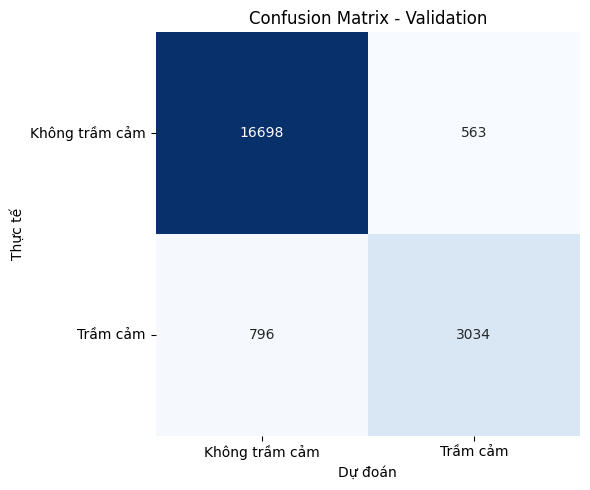

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Đánh giá trên tập validation
y_val_pred = rf_model.predict(X_val)
val_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1-score': f1_score(y_val, y_val_pred)
}

# Classification report
for name, val in val_metrics.items():
    print(f'{name:<10}: {val:.4f}')
print(classification_report(y_val, y_val_pred, target_names=['Không trầm cảm', 'Trầm cảm']))

# Confusion matrix
val_cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Validation')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.xticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'])
plt.yticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'], rotation=0)
plt.tight_layout()
plt.show()

#### Đánh giá trên tập test

Accuracy  : 0.9317
Precision : 0.8359
Recall    : 0.7763
F1-score  : 0.8050
                precision    recall  f1-score   support

Không trầm cảm       0.95      0.97      0.96     17261
      Trầm cảm       0.84      0.78      0.80      3831

      accuracy                           0.93     21092
     macro avg       0.89      0.87      0.88     21092
  weighted avg       0.93      0.93      0.93     21092



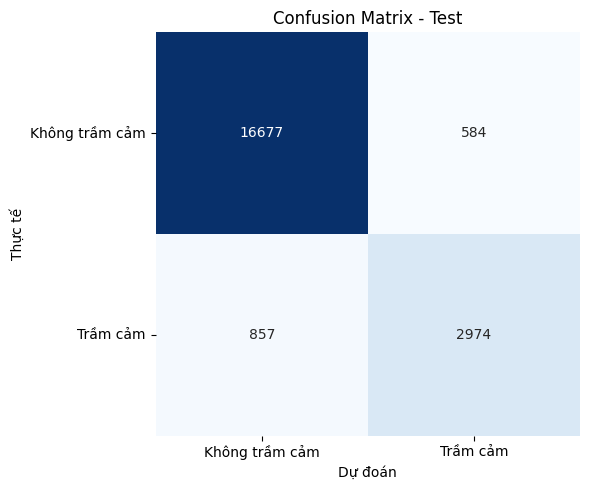

In [12]:
y_test_pred = rf_model.predict(X_test)
test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-score': f1_score(y_test, y_test_pred)
}

# Classification report
for name, val in test_metrics.items():
    print(f'{name:<10}: {val:.4f}')
print(classification_report(y_test, y_test_pred, target_names=['Không trầm cảm', 'Trầm cảm']))

# Confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.xticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'])
plt.yticks([0.5, 1.5], ['Không trầm cảm', 'Trầm cảm'], rotation=0)
plt.tight_layout()
plt.show()

#### Nhận xét
Mô hình Random Forest cho kết quả khá tốt trên cả validation và test, với accuracy khoảng 93% và F1-score khoảng 0.81 trên tập test. Điều này cho thấy mô hình tổng quát hóa ổn, vì chênh lệch giữa validation và test không lớn.

Tuy nhiên, recall của lớp 'Trầm cảm' vẫn thấp hơn lớp 'Không trầm cảm', nên mô hình còn bỏ sót một phần người có nguy cơ trầm cảm.

## LightGBM

### Giới thiệu model

LightGBM (Light Gradient Boosting Machine) là một thuật toán học máy thuộc nhóm ensemble, hoạt động bằng cách kết hợp nhiều cây quyết định để đưa ra dự đoán chính xác hơn. Mô hình được huấn luyện theo từng bước: mỗi cây mới sẽ học từ những lỗi mà các cây trước đó dự đoán sai, nhờ đó kết quả được cải thiện dần theo thời gian. Ngoài ra, LightGBM còn sử dụng một số kỹ thuật tối ưu để tăng tốc độ huấn luyện và giảm bộ nhớ sử dụng, giúp mô hình chạy nhanh và hiệu quả hơn trên tập dữ liệu lớn.

### Lý do chọn model

LightGBM được lựa chọn vì phù hợp với đặc điểm của dữ liệu và mục tiêu của bài toán.  

- Dữ liệu sử dụng là dữ liệu dạng bảng với nhiều thuộc tính khác nhau (số và phân loại), và LightGBM là mô hình xử lý rất hiệu quả loại dữ liệu này.  

- Mô hình có thể làm việc trực tiếp với các biến phân loại, giúp giảm bước tiền xử lý và giữ được thông tin quan trọng từ dữ liệu ban đầu.  

- Bài toán có sự mất cân bằng giữa các lớp (số lượng mẫu thuộc lớp cần dự đoán ít hơn), nên LightGBM cho phép điều chỉnh trọng số để cải thiện khả năng nhận diện đúng lớp này.  

- Ngoài ra, mô hình có tốc độ huấn luyện nhanh, thuận tiện cho việc thử nghiệm và tối ưu trong quá trình xây dựng mô hình.

In [13]:
!pip install lightgbm -q

import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


CHUẨN BỊ FEATURES CHO LIGHTGBM

In [14]:
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()
X_test_lgb  = X_test.copy()

# Xử lý CGPA = -1.0 → NaN
for df_part in [X_train_lgb, X_val_lgb, X_test_lgb]:
    df_part['CGPA'] = df_part['CGPA'].replace(-1.0, np.nan)

print(f"CGPA = NaN sau xử lý: {X_train_lgb['CGPA'].isna().sum():,} dòng (bình thường - đây là Working Professional)")

# Ép kiểu category
cat_cols_lgb = X_train_lgb.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols_lgb:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col]   = X_val_lgb[col].astype('category')
    X_test_lgb[col]  = X_test_lgb[col].astype('category')

print(f"Categorical columns ({len(cat_cols_lgb)}): {cat_cols_lgb}")
print(f"Numeric columns: {[c for c in X_train_lgb.columns if c not in cat_cols_lgb]}")

CGPA = NaN sau xử lý: 78,907 dòng (bình thường - đây là Working Professional)
Categorical columns (10): ['City', 'Working Professional or Student', 'Profession', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Family History of Mental Illness', 'Age_Group', 'Diet_Work_Interaction', 'Sleep_Work_Interaction']
Numeric columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress', 'bad_sleep', 'bad_work', 'bad_diet', 'bad_habits_count']


### TRAIN

Mô hình LightGBM được huấn luyện trên tập train với các tham số đã được thiết lập để đảm bảo kết quả ổn định và hạn chế overfitting.  

Do dữ liệu bị mất cân bằng giữa hai lớp, tham số `scale_pos_weight` được tính từ tỷ lệ số lượng mẫu của mỗi lớp, giúp mô hình chú ý nhiều hơn đến lớp thiểu số.  

Trong quá trình huấn luyện, mô hình sử dụng thêm tập validation để theo dõi hiệu suất. Kỹ thuật early stopping được áp dụng, nghĩa là quá trình train sẽ tự động dừng lại khi kết quả trên validation không còn cải thiện.  

Ngoài ra, mô hình được chạy trên GPU nhằm tăng tốc độ huấn luyện và hỗ trợ quá trình thử nghiệm hiệu quả hơn.

In [15]:
# TRAIN LIGHTGBM
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

train_data = lgb.Dataset(X_train_lgb, label=y_train)
val_data   = lgb.Dataset(X_val_lgb,   label=y_val, reference=train_data)

params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'verbosity': -1,
    'learning_rate': 0.02,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'reg_alpha': 0.3,
    'reg_lambda': 0.1,
    'min_gain_to_split': 0.005,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'device': 'gpu',
    'n_jobs': -1,
    'seed': 42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
]

print("Bắt đầu train...")
model_lgb = lgb.train(
    params,
    train_set=train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)
print(f"Best iteration: {model_lgb.best_iteration}")

scale_pos_weight = 4.51
Bắt đầu train...
Training until validation scores don't improve for 50 rounds
[50]	train's binary_logloss: 0.248736	train's auc: 0.975057	val's binary_logloss: 0.252501	val's auc: 0.970957
[100]	train's binary_logloss: 0.209593	train's auc: 0.977183	val's binary_logloss: 0.216864	val's auc: 0.972162
[150]	train's binary_logloss: 0.196703	train's auc: 0.978961	val's binary_logloss: 0.207102	val's auc: 0.97302
[200]	train's binary_logloss: 0.189687	train's auc: 0.980424	val's binary_logloss: 0.202815	val's auc: 0.973654
[250]	train's binary_logloss: 0.183874	train's auc: 0.98172	val's binary_logloss: 0.19997	val's auc: 0.974072
[300]	train's binary_logloss: 0.178503	train's auc: 0.982857	val's binary_logloss: 0.197788	val's auc: 0.974289
[350]	train's binary_logloss: 0.173495	train's auc: 0.983798	val's binary_logloss: 0.195899	val's auc: 0.974364
[400]	train's binary_logloss: 0.169016	train's auc: 0.984611	val's binary_logloss: 0.194225	val's auc: 0.97439
[450]	t

### TỐI ƯU THRESHOLD

Khác với cách phân loại mặc định sử dụng ngưỡng 0.5, mô hình tiến hành tìm threshold tối ưu trên tập validation.  

Tiêu chí lựa chọn:
- Ưu tiên Recall ≥ 0.85 để giảm thiểu việc bỏ sót người trầm cảm  
- Trong các threshold thỏa điều kiện, chọn giá trị có F1-score cao nhất  

Cách tiếp cận này phù hợp với bài toán thực tế, vì việc bỏ sót người có nguy cơ trầm cảm (False Negative) nguy hiểm hơn so với dự đoán nhầm.

Tìm thấy 56 threshold có Recall >= 0.85
Threshold tốt nhất: 0.74
F1=0.8343  Recall=0.8556  Precision=0.8140


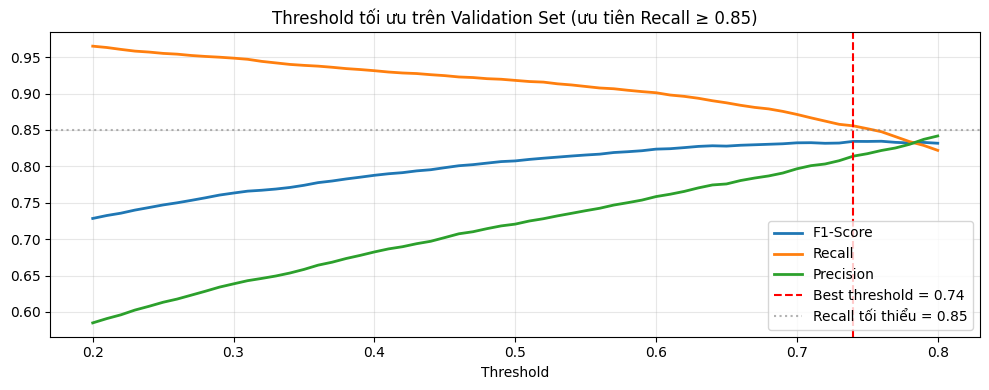

In [16]:
# TỐI ƯU THRESHOLD TRÊN VALIDATION SET
val_proba = model_lgb.predict(X_val_lgb, num_iteration=model_lgb.best_iteration)

thresholds = np.arange(0.2, 0.8, 0.01)
results = []
for t in thresholds:
    preds = (val_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'f1':        f1_score(y_val, preds),
        'recall':    recall_score(y_val, preds),
        'precision': precision_score(y_val, preds),
    })

results_df = pd.DataFrame(results)

# Ưu tiên Recall >= 0.85 trước, sau đó lấy F1 cao nhất trong nhóm đó
# Lý do: bài toán sàng lọc tâm lý - bỏ sót người bệnh nguy hiểm hơn đoán nhầm
RECALL_MIN = 0.85
candidates = results_df[results_df['recall'] >= RECALL_MIN]

if len(candidates) > 0:
    best_row = candidates.loc[candidates['f1'].idxmax()]
    print(f"Tìm thấy {len(candidates)} threshold có Recall >= {RECALL_MIN}")
else:
    best_row = results_df.loc[results_df['f1'].idxmax()]
    print(f"Không có threshold nào đạt Recall >= {RECALL_MIN}, fallback về max F1")

BEST_THRESHOLD = best_row['threshold']
print(f"Threshold tốt nhất: {BEST_THRESHOLD:.2f}")
print(f"F1={best_row['f1']:.4f}  Recall={best_row['recall']:.4f}  Precision={best_row['precision']:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_df['threshold'], results_df['f1'],        label='F1-Score',  linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'],    label='Recall',    linewidth=2)
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', linewidth=2)
ax.axvline(x=BEST_THRESHOLD, color='red', linestyle='--',
           label=f'Best threshold = {BEST_THRESHOLD:.2f}')
ax.axhline(y=RECALL_MIN, color='gray', linestyle=':', alpha=0.6,
           label=f'Recall tối thiểu = {RECALL_MIN}')
ax.set_xlabel('Threshold')
ax.set_title('Threshold tối ưu trên Validation Set (ưu tiên Recall ≥ 0.85)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Nhận xét biểu đồ

+ Khi threshold tăng, Recall giảm trong khi Precision tăng, thể hiện sự đánh đổi giữa việc phát hiện đúng và dự đoán chính xác.  

+ Tại threshold = 0.74, mô hình đạt Recall ≥ 0.85 và F1-score cao, cho thấy đây là điểm cân bằng phù hợp với mục tiêu bài toán.

#### ĐÁNH GIÁ TRÊN TEST SET

KẾT QUẢ TRÊN INTERNAL TEST SET
Accuracy : 0.9377
F1-Score : 0.8319
Recall   : 0.8496
Precision: 0.8150
AUC-ROC  : 0.9743

                precision    recall  f1-score   support

Không trầm cảm       0.97      0.96      0.96     17261
      Trầm cảm       0.81      0.85      0.83      3831

      accuracy                           0.94     21092
     macro avg       0.89      0.90      0.90     21092
  weighted avg       0.94      0.94      0.94     21092



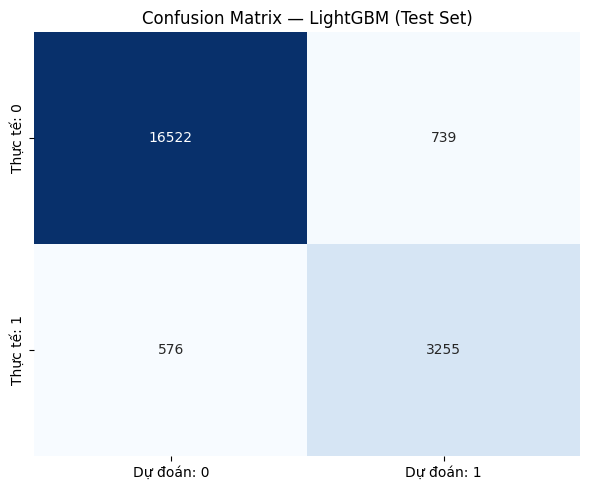

True Negative  (đoán đúng người khỏe): 16,522
False Positive (đoán nhầm là bệnh):    739
False Negative (BỎ SÓT người bệnh ): 576
True Positive  (đoán đúng người bệnh): 3,255


In [17]:
# ĐÁNH GIÁ TRÊN TEST SET
test_proba = model_lgb.predict(X_test_lgb, num_iteration=model_lgb.best_iteration)
test_preds = (test_proba >= BEST_THRESHOLD).astype(int)

print("=" * 55)
print("KẾT QUẢ TRÊN INTERNAL TEST SET")
print("=" * 55)
print(f"Accuracy : {accuracy_score(y_test, test_preds):.4f}")
print(f"F1-Score : {f1_score(y_test, test_preds):.4f}")
print(f"Recall   : {recall_score(y_test, test_preds):.4f}")
print(f"Precision: {precision_score(y_test, test_preds):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, test_proba):.4f}")
print()
print(classification_report(y_test, test_preds,
      target_names=['Không trầm cảm', 'Trầm cảm']))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dự đoán: 0', 'Dự đoán: 1'],
            yticklabels=['Thực tế: 0', 'Thực tế: 1'])
ax.set_title('Confusion Matrix — LightGBM (Test Set)')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (đoán đúng người khỏe): {tn:,}")
print(f"False Positive (đoán nhầm là bệnh):    {fp:,}")
print(f"False Negative (BỎ SÓT người bệnh ): {fn:,}")
print(f"True Positive  (đoán đúng người bệnh): {tp:,}")

#### Phân tích confusion matrix

Confusion matrix cho thấy khả năng dự đoán của mô hình trên từng lớp:

- True Positive: dự đoán đúng người trầm cảm  
- True Negative: dự đoán đúng người không trầm cảm  
- False Positive: dự đoán nhầm người không trầm cảm thành trầm cảm  
- False Negative: bỏ sót người trầm cảm  

Trong bài toán này, False Negative là trường hợp cần hạn chế nhất.  

#### Nhận xét

Mô hình LightGBM cho kết quả tốt trên tập test với accuracy khoảng 94% và F1-score khoảng 0.83. Các chỉ số Precision và Recall đều ở mức khá cao, cho thấy mô hình dự đoán ổn định và đáng tin cậy.  

Đặc biệt, Recall của lớp 'Trầm cảm' đạt mức cao, cho thấy mô hình phát hiện được phần lớn các trường hợp có nguy cơ, phù hợp với mục tiêu của bài toán.  

Nhìn chung, mô hình hoạt động hiệu quả và đáp ứng tốt yêu cầu trong bài toán dự đoán.

####ĐÁNH GIÁ TẦM QUAN TRỌNG CỦA ĐẶC TRƯNG

Biểu đồ feature importance cho thấy mức độ ảnh hưởng của từng đặc trưng đến kết quả dự đoán của mô hình.  

Những đặc trưng có giá trị cao là những yếu tố mà mô hình dựa vào nhiều để phân biệt giữa hai nhóm.  

Việc phân tích này giúp hiểu rõ hơn cách mô hình hoạt động và hỗ trợ cho việc cải thiện mô hình trong tương lai.

Top 10 features quan trọng nhất:
                              feature  importance_gain  importance_split
                                  Age     1.475623e+06              3890
                            Age_Group     4.435743e+05               490
Have_you_ever_had_suicidal_thoughts_?     3.203116e+05               549
                           Profession     2.725729e+05              3699
                     Financial_Stress     1.468758e+05              1748
                        Work_Pressure     1.299857e+05              1718
                    Academic_Pressure     1.267054e+05              1183
                                 City     1.230659e+05              4789
                     Job_Satisfaction     1.067239e+05              1619
                Diet_Work_Interaction     6.865239e+04              1857


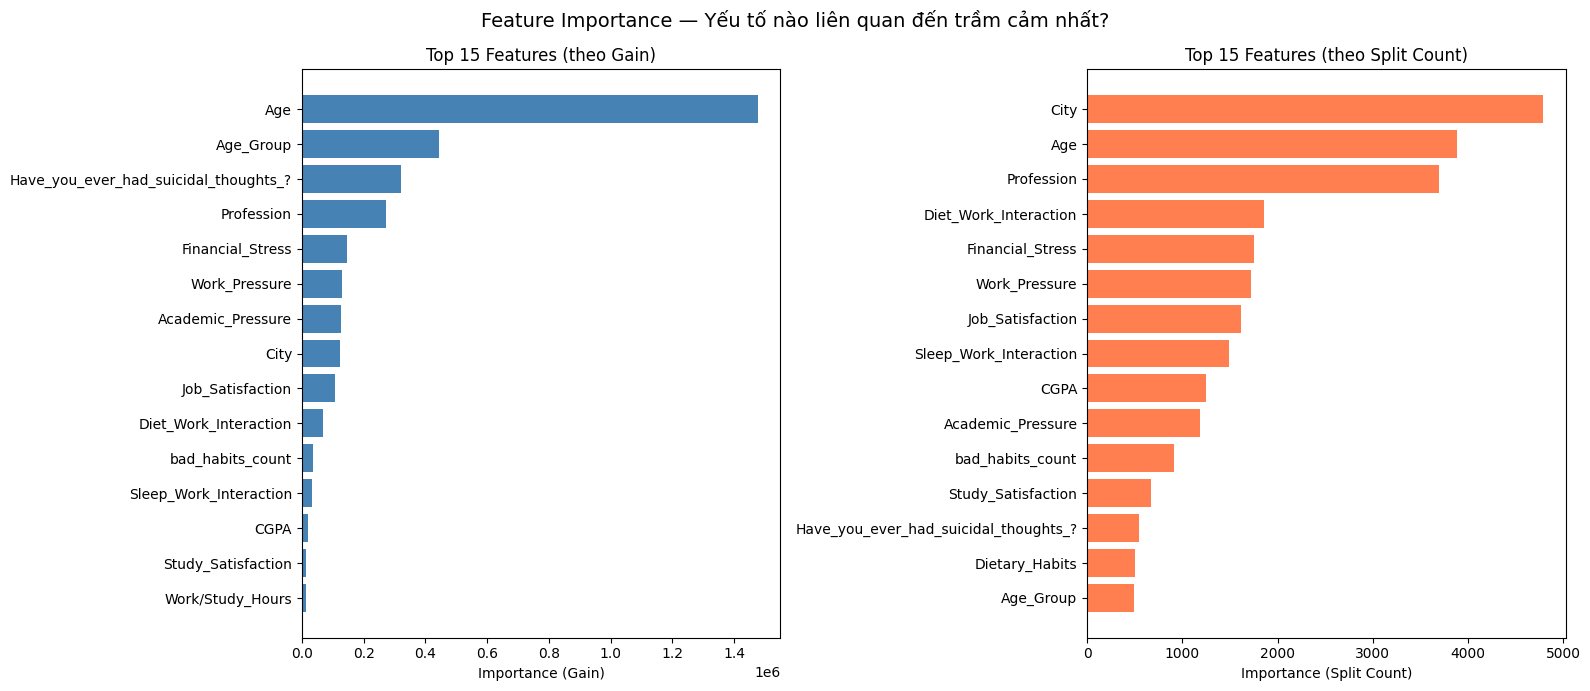

In [19]:
# FEATURE IMPORTANCE
feat_df = pd.DataFrame({
    'feature':          model_lgb.feature_name(),
    'importance_gain':  model_lgb.feature_importance(importance_type='gain'),
    'importance_split': model_lgb.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False)

print("Top 10 features quan trọng nhất:")
print(feat_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_n = 15
for ax, col, color, label in zip(
    axes,
    ['importance_gain', 'importance_split'],
    ['steelblue', 'coral'],
    ['Gain', 'Split Count']
):
    top = feat_df.sort_values(col, ascending=False).head(top_n)
    ax.barh(top['feature'][::-1], top[col][::-1], color=color)
    ax.set_title(f'Top {top_n} Features (theo {label})')
    ax.set_xlabel(f'Importance ({label})')

plt.suptitle('Feature Importance — Yếu tố nào liên quan đến trầm cảm nhất?',
             fontsize=14)
plt.tight_layout(); plt.show()

#### Nhận xét

+ Biểu đồ feature importance cho thấy Age (tuổi) là yếu tố quan trọng nhất, có ảnh hưởng lớn nhất đến quyết định của mô hình.  

+ Các yếu tố tiếp theo như Age_Group, suy nghĩ tiêu cực, nghề nghiệp (Profession) cũng có mức ảnh hưởng đáng kể, cho thấy các đặc điểm cá nhân và tâm lý đóng vai trò quan trọng trong việc phân biệt hai nhóm.  

+ Bên cạnh đó, các yếu tố liên quan đến áp lực như Financial_Stress, Work_Pressure, Academic_Pressure và mức độ hài lòng (Job_Satisfaction) cũng góp phần ảnh hưởng đến kết quả dự đoán.  

+ Ngoài ra, các đặc trưng như City có số lần được sử dụng nhiều (split cao), cho thấy mô hình thường xuyên dùng chúng để phân chia dữ liệu, dù mức độ ảnh hưởng tổng thể không cao bằng.  

+ Nhìn chung, mô hình đang dựa nhiều vào các yếu tố về độ tuổi, trạng thái tâm lý và áp lực trong cuộc sống để đưa ra dự đoán.